In [ ]:
import os
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms, models
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!tar -xf "/content/drive/MyDrive/computer vision/hw1/cv_hw1_data.tar" -C /content/

In [ ]:
data_dir = "/content/data"

train_dir = os.path.join(data_dir, "train")
val_dir = os.path.join(data_dir, "val")
test_dir = os.path.join(data_dir, "test")



In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("Using device:", device)

Using device: cpu


## Define transform
### 1. Resize
### 2. 轉成Tensor
### 3. Normalize

In [ ]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05,
    ),
    transforms.RandAugment(num_ops=2, magnitude=8),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.25),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

## 載入 train/val

In [ ]:
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=val_test_transform)
num_classes = len(train_dataset.classes)
print("Number of classes:", num_classes)
classes = train_dataset.classes
sorted_classes = sorted(classes, key=lambda x: int(x))

class_to_idx_fixed = {cls_name: i for i, cls_name in enumerate(sorted_classes)}
idx_to_class_fixed = {
    i: int(cls_name)
    for cls_name, i in class_to_idx_fixed.items()
}

Number of classes: 100


In [8]:
class TestDataset(Dataset):
    def __init__(self, test_dir, transform=None):
        self.test_dir = test_dir
        self.transform = transform

        self.image_names = sorted([
            f for f in os.listdir(test_dir)
            if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.webp'))
        ])

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        img_path = os.path.join(self.test_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, img_name

In [9]:
test_dataset = TestDataset(test_dir, transform=val_test_transform)

## 建立data loader

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
)

## 載入 ResNet

In [ ]:
model = models.resnext101_32x8d(
    weights=models.ResNeXt101_32X8D_Weights.IMAGENET1K_V2
)

model.fc = nn.Linear(model.fc.in_features, num_classes)

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/computer vision/hw1/"
        "best2_resnext101-pretrain7_aug.pth"
    )
)
model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnext101_32x8d-110c445d.pth" to /root/.cache/torch/hub/checkpoints/resnext101_32x8d-110c445d.pth


100%|██████████| 340M/340M [00:01<00:00, 223MB/s]


RuntimeError: Attempting to deserialize object on a CUDA device but torch.cuda.is_available() is False. If you are running on a CPU-only machine, please use torch.load with map_location=torch.device('cpu') to map your storages to the CPU.

In [ ]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW([
    {"params": model.fc.parameters(), "lr": 1e-4},
    {
        "params": [
            p
            for n, p in model.named_parameters()
            if not n.startswith("fc.")
        ],
        "lr": 1e-5,
    }
], weight_decay=1e-3)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    loop = tqdm(loader, desc="Training")

    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        loop.set_postfix(loss=loss.item(), acc=correct / total)

    return running_loss / total, correct / total

In [15]:
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

## Train model

In [ ]:
num_epochs = 20
best_val_acc = 0.0

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device,
    )
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(
            model.state_dict(),
            "/content/drive/MyDrive/computer vision/hw1/"
            "best2_resnext101-pretrain8_aug.pth",
        )
        print("Best model saved.")

Training: 100%|██████████| 324/324 [03:35<00:00,  1.50it/s, acc=0.978, loss=0.0442]


Epoch [1/20]
Train Loss: 0.0764, Train Acc: 0.9782
Val   Loss: 0.6440, Val   Acc: 0.8833
Best model saved.


Training: 100%|██████████| 324/324 [03:35<00:00,  1.50it/s, acc=0.98, loss=0.0345]


Epoch [2/20]
Train Loss: 0.0700, Train Acc: 0.9803
Val   Loss: 0.6048, Val   Acc: 0.8967
Best model saved.


Training: 100%|██████████| 324/324 [03:35<00:00,  1.50it/s, acc=0.982, loss=0.0867]


...

Epoch [13/20]
Train Loss: 0.0438, Train Acc: 0.9869
Val   Loss: 0.6059, Val   Acc: 0.8767


Training: 100%|██████████| 324/324 [03:35<00:00,  1.51it/s, acc=0.986, loss=0.0509]


Epoch [14/20]
Train Loss: 0.0492, Train Acc: 0.9859
Val   Loss: 0.6024, Val   Acc: 0.8833


Training:   8%|▊         | 26/324 [00:17<03:25,  1.45it/s, acc=0.986, loss=0.0368]


KeyboardInterrupt: 

## Ensemble

100%|██████████| 5/5 [02:45<00:00, 33.11s/it]


Ensemble Val Accuracy: 0.9200


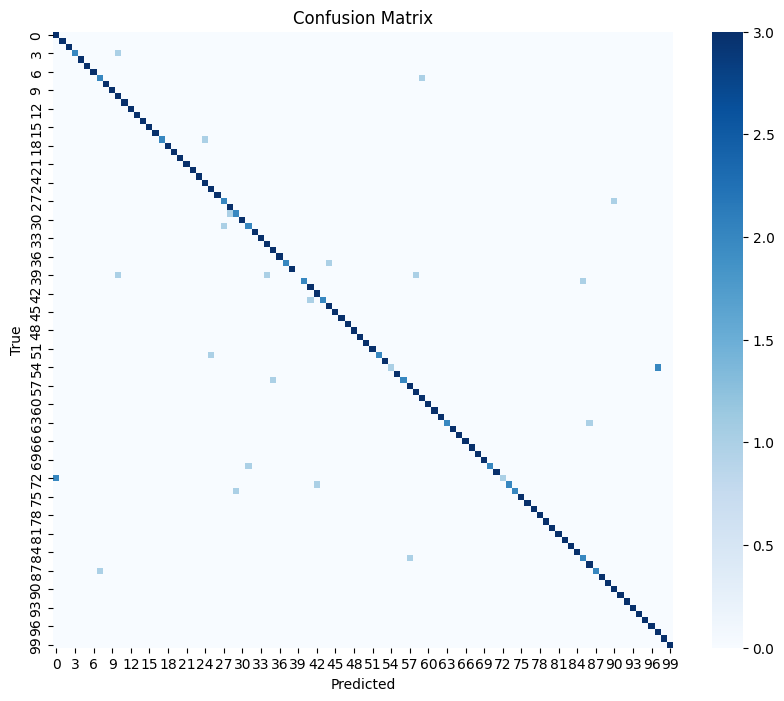

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 100

def build_model(num_classes):
    model = models.resnext101_32x8d(
        weights=models.ResNeXt101_32X8D_Weights.IMAGENET1K_V2
    )
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def load_model(ckpt_path):
    model = build_model(num_classes)
    state_dict = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    return model


model5 = load_model(
    "/content/drive/MyDrive/computer vision/hw1/"
    "best2_resnext101-pretrain5_aug.pth"
)
model6 = load_model(
    "/content/drive/MyDrive/computer vision/hw1/"
    "best2_resnext101-pretrain6_aug.pth"
)
model7 = load_model(
    "/content/drive/MyDrive/computer vision/hw1/"
    "best2_resnext101-pretrain7_aug.pth"
)


models_list = [model5, model6, model7]
correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(val_loader):
        images = images.to(device)
        labels = labels.to(device)

        logits_sum = 0
        for model in models_list:
            logits = model(images)
            logits_sum += logits

        logits_avg = logits_sum / len(models_list)
        preds = torch.argmax(logits_avg, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

val_acc = correct / total
print(f"Ensemble Val Accuracy: {val_acc:.4f}")

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


## Test model

In [ ]:
model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/computer vision/hw1/"
        "best2_resnext101-pretrain6_aug.pth"
    )
)
model = model.to(device)
model.eval()

idx_to_class = {v: int(k) for k, v in train_dataset.class_to_idx.items()}

predictions = []

with torch.no_grad():
    for images, img_names in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        for img_name, pred in zip(img_names, preds):
            real_label = idx_to_class[pred.item()]
            predictions.append((img_name.rsplit('.', 1)[0], real_label))

## Ensemble test

In [ ]:
model5 = load_model(
    "/content/drive/MyDrive/computer vision/hw1/"
    "best2_resnext101-pretrain5_aug.pth"
)
model6 = load_model(
    "/content/drive/MyDrive/computer vision/hw1/"
    "best2_resnext101-pretrain6_aug.pth"
)
model7 = load_model(
    "/content/drive/MyDrive/computer vision/hw1/"
    "best2_resnext101-pretrain7_aug.pth"
)

model5 = model5.to(device)
model6 = model6.to(device)
model7 = model7.to(device)

model5.eval()
model6.eval()
model7.eval()

idx_to_class = {v: int(k) for k, v in train_dataset.class_to_idx.items()}

predictions = []

with torch.no_grad():
    for images, img_names in test_loader:
        images = images.to(device)

        outputs5 = model5(images)
        outputs6 = model6(images)
        outputs7 = model7(images)

        ensemble_outputs = (outputs5 + outputs6 + outputs7) / 3.0
        _, preds = torch.max(ensemble_outputs, 1)

        for img_name, pred in zip(img_names, preds):
            real_label = idx_to_class[pred.item()]
            predictions.append((img_name.rsplit('.', 1)[0], real_label))

## output CSV

In [ ]:
df = pd.DataFrame(predictions, columns=["image_name", "pred_label"])
df.to_csv(
    "/content/drive/MyDrive/computer vision/hw1/"
    "predictions_ensemble-resnext101.csv",
    index=False,
)

print(df.head())

                             image_name  pred_label
0  001a74bd-6679-4709-aa0b-d10277f057e6          51
1  002fe951-e857-4ebf-8de4-53c89b9f324e          13
2  0042dfce-6c3e-4528-a306-5ac3c1cb6bb8          39
3  008e97fa-a96b-49f1-9c23-554ffb5ba0f0          10
4  00a10414-db4c-44c8-a5dd-ca47ee4d37f4          34
